Usando o exemplo 499

In [1]:
%pip install pandas numpy seaborn tensorflow
%pip install nltk
%pip install lime
%pip install imbalanced-learn
%pip install shap

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.2.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.2.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.2.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.2.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.2.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
import pandas as pd
import numpy as np
import re
import seaborn as sns
import matplotlib.pyplot as plt
import shap


from lime import lime_text
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score
from sklearn.preprocessing import LabelEncoder

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from sklearn.feature_extraction.text import TfidfVectorizer

c:\Users\LUIRYS SILVA\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
df = pd.read_csv('../Tweets.csv')

In [4]:
df.head()

,tweet_id,airline_sentiment,airline_sentiment_confidence,negativereason,negativereason_confidence,airline,airline_sentiment_gold,name,negativereason_gold,retweet_count,text,tweet_coord,tweet_created,tweet_location,user_timezone
0,570306133677760513,neutral,1.0,NaN,NaN,Virgin America,NaN,cairdin,NaN,0,@VirginAmerica What @dhepburn said.,NaN,2015-02-24 11:35:52 -0800,NaN,Eastern Time (US & Canada)
1,570301130888122368,positive,3.486,NaN,0.0,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica plus you've added commercials t...,NaN,2015-02-24 11:15:59 -0800,NaN,Pacific Time (US & Canada)
2,570301083672813571,neutral,6.837,NaN,NaN,Virgin America,NaN,yvonnalynn,NaN,0,@VirginAmerica I didn't today... Must mean I n...,NaN,2015-02-24 11:15:48 -0800,Lets Play,Central Time (US & Canada)
3,570301031407624196,negative,1.0,Bad Flight,7.033,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica it's really aggressive to blast...,NaN,2015-02-24 11:15:36 -0800,NaN,Pacific Time (US & Canada)
4,570300817074462722,negative,1.0,Can't Tell,1.0,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica and it's a really big bad thing...,NaN,2015-02-24 11:14:45 -0800,NaN,Pacific Time (US & Canada)


In [5]:
df.shape

(14640, 15)

<Axes: xlabel='airline_sentiment', ylabel='count'>

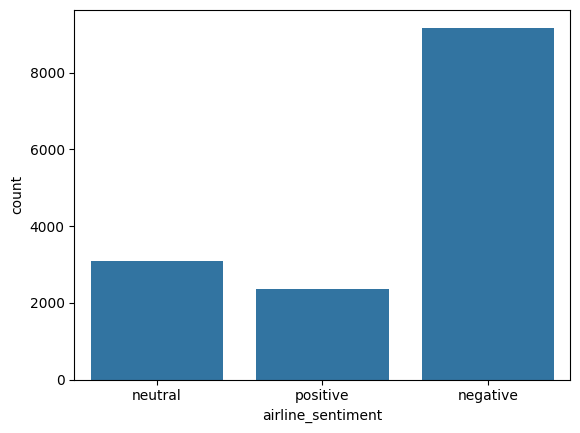

In [6]:
sns.countplot(x='airline_sentiment', data=df)

**Pré-Processamento**

In [7]:
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
import re

# Baixar pacotes necessários do NLTK
nltk.download("stopwords")
nltk.download("punkt")
nltk.download("wordnet")
nltk.download('punkt_tab') # Download the 'punkt_tab' resource

[nltk_data] Downloading package stopwords to C:\Users\LUIRYS
[nltk_data]     SILVA\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to C:\Users\LUIRYS
[nltk_data]     SILVA\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to C:\Users\LUIRYS
[nltk_data]     SILVA\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt_tab to C:\Users\LUIRYS
[nltk_data]     SILVA\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [8]:
def preprocess_text(text):
    # Converter para minúsculas
    text = text.lower()

    # Remover caracteres especiais e números
    text = re.sub(r"[^a-zA-Z\s]", "", text)

    # Tokenização (dividir em palavras)
    tokens = word_tokenize(text)

    # Remover stopwords
    stop_words = set(stopwords.words("english"))
    tokens = [word for word in tokens if word not in stop_words]

    # Lematização (reduzir palavras à sua forma base)
    lemmatizer = WordNetLemmatizer()
    tokens = [lemmatizer.lemmatize(word) for word in tokens]

    # Juntar as palavras processadas de volta em uma string
    return " ".join(tokens)

In [9]:
df["clean_text"] = df["text"].apply(preprocess_text)

In [10]:
df.head(5)

,tweet_id,airline_sentiment,airline_sentiment_confidence,negativereason,negativereason_confidence,airline,airline_sentiment_gold,name,negativereason_gold,retweet_count,text,tweet_coord,tweet_created,tweet_location,user_timezone,clean_text
0,570306133677760513,neutral,1.0,NaN,NaN,Virgin America,NaN,cairdin,NaN,0,@VirginAmerica What @dhepburn said.,NaN,2015-02-24 11:35:52 -0800,NaN,Eastern Time (US & Canada),virginamerica dhepburn said
1,570301130888122368,positive,3.486,NaN,0.0,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica plus you've added commercials t...,NaN,2015-02-24 11:15:59 -0800,NaN,Pacific Time (US & Canada),virginamerica plus youve added commercial expe...
2,570301083672813571,neutral,6.837,NaN,NaN,Virgin America,NaN,yvonnalynn,NaN,0,@VirginAmerica I didn't today... Must mean I n...,NaN,2015-02-24 11:15:48 -0800,Lets Play,Central Time (US & Canada),virginamerica didnt today must mean need take ...
3,570301031407624196,negative,1.0,Bad Flight,7.033,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica it's really aggressive to blast...,NaN,2015-02-24 11:15:36 -0800,NaN,Pacific Time (US & Canada),virginamerica really aggressive blast obnoxiou...
4,570300817074462722,negative,1.0,Can't Tell,1.0,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica and it's a really big bad thing...,NaN,2015-02-24 11:14:45 -0800,NaN,Pacific Time (US & Canada),virginamerica really big bad thing


<Axes: xlabel='airline_sentiment', ylabel='count'>

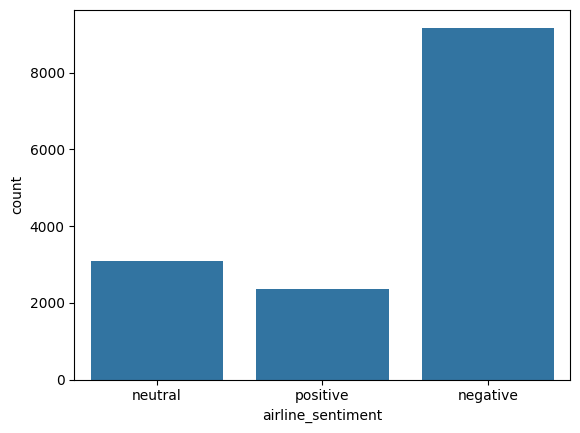

In [11]:
sns.countplot(x="airline_sentiment", data=df) # validando se mudou as classes

In [12]:
le = LabelEncoder()
df['label_encoded'] = le.fit_transform(df['airline_sentiment'])

In [13]:
X = df['clean_text']
y = df['label_encoded']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
#, stratify=y

In [14]:
tfidf = TfidfVectorizer(
    max_features=5000,
    stop_words=None
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

**UNDERSAMPLING**

In [35]:
from imblearn.under_sampling import RandomUnderSampler

# Inicializar o RandomUnderSampler
rus = RandomUnderSampler(random_state=42) # random_state para reprodutibilidade

# Aplicar o undersampling aos dados de treino
X_train_resampled, y_train_resampled = rus.fit_resample(X_train_tfidf, y_train)

<Axes: xlabel='label_encoded', ylabel='count'>

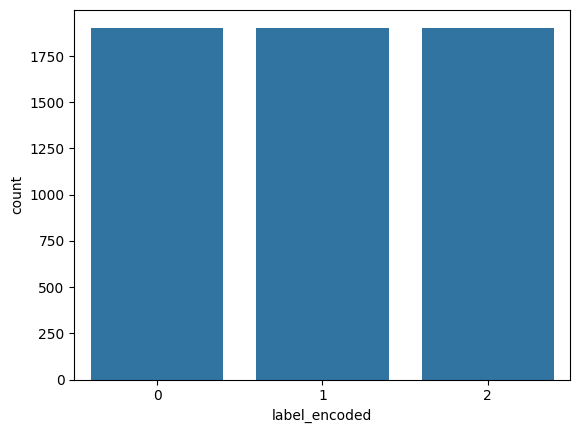

In [36]:
#verificar a nova distribuição de classes
sns.countplot(x=y_train_resampled)

**MLP**

In [37]:
model = Sequential()

model.add(Dense(
    256,
    activation='relu',
    input_shape=(X_train_tfidf.shape[1],)
))

model.add(Dropout(0.5))

model.add(Dense(
    128,
    activation='relu'
))

model.add(Dropout(0.3))

model.add(Dense(
    3,
    activation='softmax'
))

c:\Users\LUIRYS SILVA\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [38]:
# Compilar o modelo
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',  # Use sparse_categorical_crossentropy se y_train for numérico
              metrics=['accuracy'])

In [39]:
# Treinar o modelo
history = model.fit(X_train_resampled, 
                    y_train_resampled,
                    epochs=10,
                    batch_size=32,
                    validation_split=0.1)  # Validação durante o treinamento

Epoch 1/10
161/161 ━━━━━━━━━━━━━━━━━━━━ 13s 58ms/step - accuracy: 0.5521 - loss: 0.9189 - val_accuracy: 0.5664 - val_loss: 0.9270
Epoch 2/10
161/161 ━━━━━━━━━━━━━━━━━━━━ 9s 50ms/step - accuracy: 0.7930 - loss: 0.5276 - val_accuracy: 0.7168 - val_loss: 0.7114
Epoch 3/10
161/161 ━━━━━━━━━━━━━━━━━━━━ 8s 46ms/step - accuracy: 0.8788 - loss: 0.3479 - val_accuracy: 0.7238 - val_loss: 0.7993
Epoch 4/10
161/161 ━━━━━━━━━━━━━━━━━━━━ 8s 52ms/step - accuracy: 0.9218 - loss: 0.2316 - val_accuracy: 0.6276 - val_loss: 1.2196
Epoch 5/10
161/161 ━━━━━━━━━━━━━━━━━━━━ 7s 43ms/step - accuracy: 0.9516 - loss: 0.1512 - val_accuracy: 0.6678 - val_loss: 1.1410
Epoch 6/10
161/161 ━━━━━━━━━━━━━━━━━━━━ 11s 47ms/step - accuracy: 0.9669 - loss: 0.1076 - val_accuracy: 0.6573 - val_loss: 1.3088
Epoch 7/10
161/161 ━━━━━━━━━━━━━━━━━━━━ 8s 48ms/step - accuracy: 0.9778 - loss: 0.0783 - val_accuracy: 0.7098 - val_loss: 1.2238
Epoch 8/10
161/161 ━━━━━━━━━━━━━━━━━━━━ 8s 49ms/step - accuracy: 0.9813 - loss: 0.0643 - val_ac

**Métricas**

In [40]:
from sklearn.metrics import classification_report

# Fazer previsões no conjunto de teste
y_pred = model.predict(X_test_tfidf)
y_pred_classes = np.argmax(y_pred, axis=1)

# Gerar o relatório de classificação
print(classification_report(y_test, y_pred_classes))


92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step
              precision    recall  f1-score   support

           0       0.88      0.73      0.80      1889
           1       0.42      0.64      0.51       580
           2       0.63      0.68      0.65       459

    accuracy                           0.70      2928
   macro avg       0.65      0.68      0.65      2928
weighted avg       0.75      0.70      0.72      2928



In [41]:
#acuracia,precisão, recall e f1-score
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
def calculate_metrics(y_true, y_pred):
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average='weighted')
    recall = recall_score(y_true, y_pred, average='weighted')
    f1 = f1_score(y_true, y_pred, average='weighted')
    
    return accuracy, precision, recall, f1
# Calcular as métricas
accuracy, precision, recall, f1 = calculate_metrics(y_test, y_pred_classes)
print(f"Acurácia: {accuracy:.4f}")
print(f"Precisão: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")

Acurácia: 0.7025
Precisão: 0.7510
Recall: 0.7025
F1-Score: 0.7177


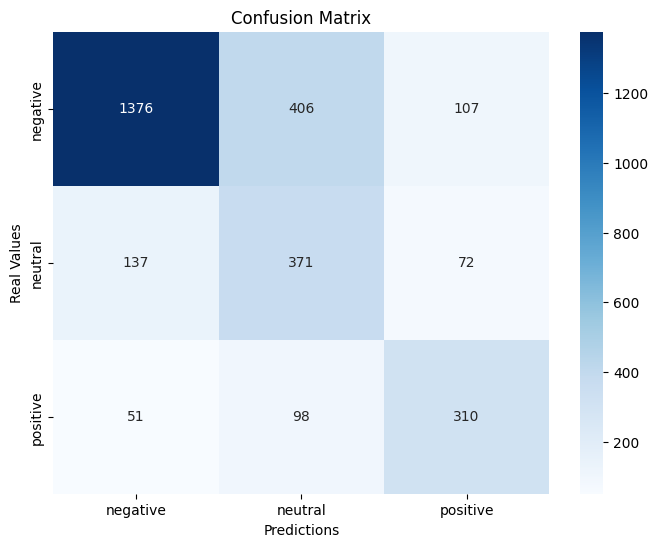

In [42]:
# Calcular a matriz de confusão
conf_matrix = confusion_matrix(y_test, y_pred_classes)

# Criar o heatmap da matriz de confusão
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues",
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel("Predictions")
plt.ylabel("Real Values")
plt.title("Confusion Matrix")
plt.show()

**LIME**

In [43]:
from lime.lime_text import LimeTextExplainer

explainer = LimeTextExplainer(class_names=le.classes_)

def predict_proba(texts):
    X = tfidf.transform(texts)
    X = X.toarray()
    return model.predict(X, verbose=0)

# Solicita ao usuário o número da linha do exemplo
idx = int(input(f"Digite o número da linha (0 a {len(X_test)-1}): "))
sample_text = X_test.iloc[idx]
sample_label = y_test.iloc[idx]

# Predição da classe para o texto selecionado
sample_tfidf = tfidf.transform([sample_text]).toarray()

pred_probs = model.predict(sample_tfidf, verbose=0)
pred_class_idx = pred_probs.argmax(axis=1)[0]
pred_class_name = le.classes_[pred_class_idx]

print(f"Número da linha no X_test: {idx}")
print(f"Original text:\n{sample_text}")
print(f"Classe real: {le.classes_[sample_label]}")
print(f"Classe predita: {pred_class_name}")

explanation = explainer.explain_instance(
    sample_text,
    predict_proba,
    num_features=10
)

print(explanation.as_list())

Número da linha no X_test: 499
Original text:
americanair narrowly made standbylots snag trip
Classe real: negative
Classe predita: positive
[(np.str_('made'), -0.4903740613092679), (np.str_('trip'), -0.3695579176386258), (np.str_('americanair'), 0.27194008614028126), (np.str_('snag'), 0.15050612945360042), (np.str_('standbylots'), 0.01943973784450614), (np.str_('narrowly'), 0.013868870462877303)]


In [44]:
# Obtém as palavras mais importantes e seus pesos
lime_features = explanation.as_list()

# Exibe cada palavra com seu impacto na predição
print("Palavras mais importantes e seus pesos:")
for word, weight in lime_features:
    print(f"{word}: {weight:.4f}")

Palavras mais importantes e seus pesos:
made: -0.4904
trip: -0.3696
americanair: 0.2719
snag: 0.1505
standbylots: 0.0194
narrowly: 0.0139


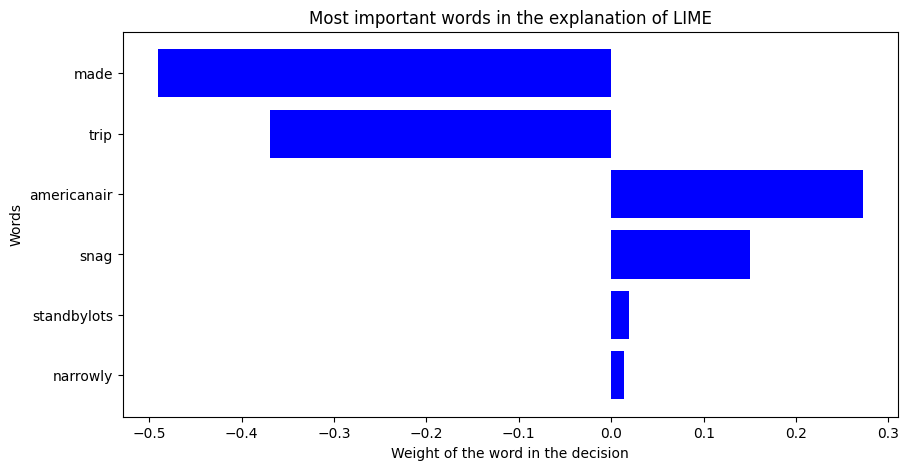

In [45]:
# Separar palavras e pesos
words, weights = zip(*lime_features)

# Criar gráfico de barras
plt.figure(figsize=(10, 5))
plt.barh(words, weights, color="blue")
plt.xlabel("Weight of the word in the decision")
plt.ylabel("Words")
plt.title("Most important words in the explanation of LIME")
plt.gca().invert_yaxis()  # Inverter para mostrar a palavra mais importante no topo
plt.show()

In [46]:
# Obter as palavras mais importantes e seus pesos no geral
words_weights = explanation.as_list()

# Imprimir as palavras e pesos
for word, weight in words_weights:
    print(f"{word}: {weight}")

made: -0.4903740613092679
trip: -0.3695579176386258
americanair: 0.27194008614028126
snag: 0.15050612945360042
standbylots: 0.01943973784450614
narrowly: 0.013868870462877303


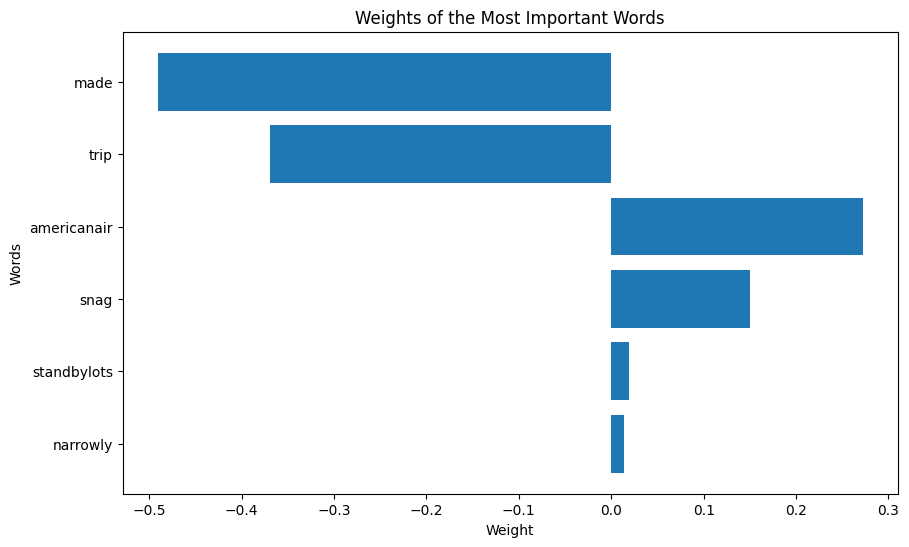

In [47]:
# Obter as palavras mais importantes e seus pesos no geral
words_weights = explanation.as_list()

# Separar palavras e pesos em listas separadas
words = [word for word, weight in words_weights]
weights = [weight for word, weight in words_weights]

# Criar o gráfico de barras horizontais
plt.figure(figsize=(10, 6))  # Ajustar o tamanho da figura, se necessário
plt.barh(words, weights)
plt.xlabel("Weight")
plt.ylabel("Words")
plt.title("Weights of the Most Important Words")
plt.gca().invert_yaxis()  # Inverter o eixo y para que as palavras mais importantes estejam no topo
plt.show()

**Attention Viz**

In [48]:
le.classes_

array(['negative', 'neutral', 'positive'], dtype=object)

Texto usado na explicação:
americanair narrowly made standbylots snag trip

Classe prevista: 2
Probabilidades: [0.0163933 0.1856051 0.7980015]
Camadas Dense encontradas:
0 dense_3 (5000, 256)
1 dense_4 (256, 128)
2 dense_5 (128, 3)

Dimensões:
W1: (5000, 256)
W2: (256, 128)
W3: (128, 3)
Global: (5000, 3)
Importance: (5000,)
TFIDF: (5000,)
Número de palavras: 4
       Feature     TFIDF    Weight  Contribution
1         made  0.431623  8.761106      3.781497
3         trip  0.429696  8.787328      3.775878
2         snag  0.763775 -0.532244     -0.406515
0  americanair  0.213800 -6.299580     -1.346849


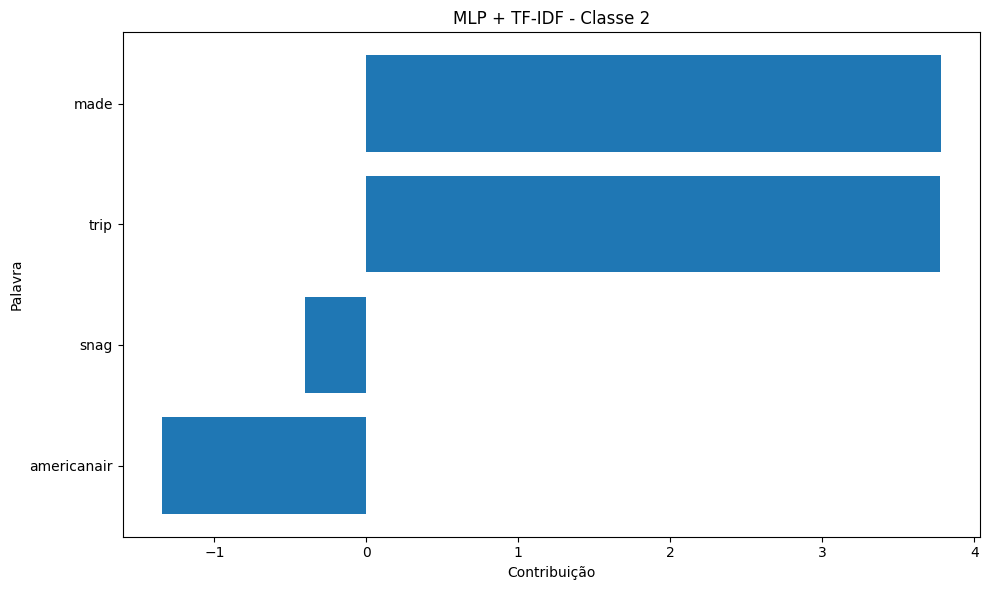

In [49]:
# =====================================================
# MESMO EXEMPLO UTILIZADO NO LIME
# =====================================================

lime_idx = 499

sample_text = X_test.iloc[lime_idx]

print("Texto usado na explicação:")
print(sample_text)

# =====================================================
# ETAPA 1: PREVISÃO DO MODELO
# =====================================================

sample_tfidf = X_test_tfidf[lime_idx:lime_idx+1]

prediction = model.predict(sample_tfidf, verbose=0)

predicted_class_index = np.argmax(prediction[0])

print(f"\nClasse prevista: {predicted_class_index}")
print("Probabilidades:", prediction[0])

# =====================================================
# ETAPA 2: IMPORTÂNCIA GLOBAL DAS FEATURES
# =====================================================

feature_names = tfidf.get_feature_names_out()

# Recuperar apenas as camadas Dense
dense_layers = [layer for layer in model.layers if "Dense" in layer.__class__.__name__]

print("Camadas Dense encontradas:")
for i, layer in enumerate(dense_layers):
    print(i, layer.name, layer.get_weights()[0].shape)

# Matrizes de pesos
W1 = dense_layers[0].get_weights()[0]
W2 = dense_layers[1].get_weights()[0]
W3 = dense_layers[2].get_weights()[0]

print("\nDimensões:")
print("W1:", W1.shape)
print("W2:", W2.shape)
print("W3:", W3.shape)

# Propagação linear dos pesos
global_weights = W1 @ W2 @ W3

print("Global:", global_weights.shape)

# Importância da classe prevista
global_importance = global_weights[:, predicted_class_index]

print("Importance:", global_importance.shape)

# =====================================================
# ETAPA 3: PALAVRAS PRESENTES NO TEXTO
# =====================================================

tfidf_vector = sample_tfidf.toarray().flatten()

print("TFIDF:", tfidf_vector.shape)

indices = np.where(tfidf_vector > 0)[0]

print("Número de palavras:", len(indices))

palavras = feature_names[indices]

pesos = global_importance[indices]

contribuicao = tfidf_vector[indices] * pesos

importancias = pd.DataFrame({
    "Feature": palavras,
    "TFIDF": tfidf_vector[indices],
    "Weight": pesos,
    "Contribution": contribuicao
})

importancias = importancias.sort_values(
    by="Contribution",
    ascending=False
)

print(importancias.head(20))

# =====================================================
# ETAPA 4: VISUALIZAÇÃO
# =====================================================

top = importancias.head(20)

plt.figure(figsize=(10,6))

plt.barh(
    top["Feature"],
    top["Contribution"]
)

plt.xlabel("Contribuição")
plt.ylabel("Palavra")
plt.title(f"MLP + TF-IDF - Classe {predicted_class_index}")

plt.gca().invert_yaxis()

plt.tight_layout()

plt.show()

Shapley

Classe prevista: 2


100%|██████████| 1/1 [00:06<00:00,  6.80s/it]


Palavras: ['trip' 'made' 'snag' 'americanair']
TF-IDF: [0.4296958  0.43162322 0.76377522 0.21379974]
SHAP: [0.27584608 0.27094478 0.         0.        ]


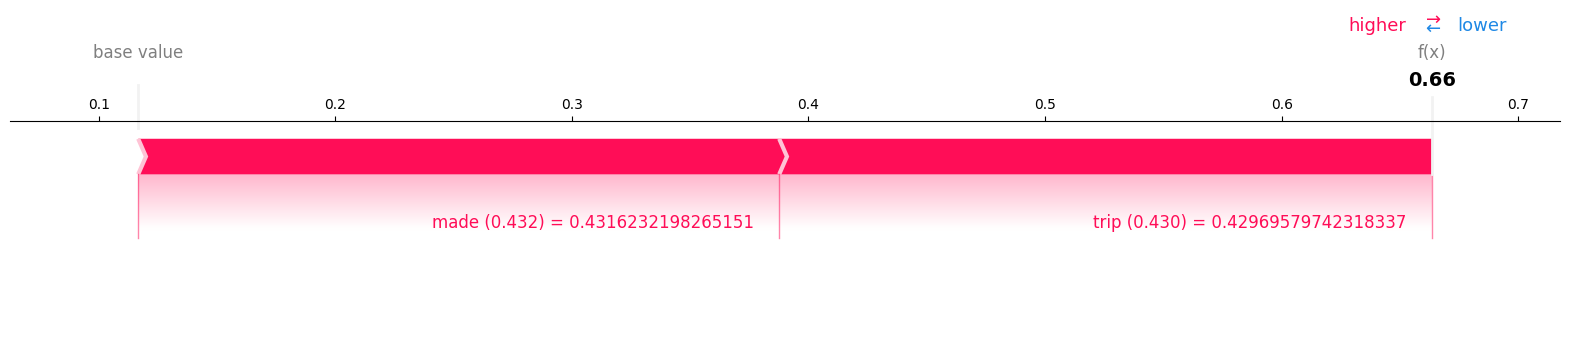

In [50]:
# =====================================================
# Mesma instância utilizada no LIME
# =====================================================

lime_idx = 499

X_instance = X_test_tfidf[lime_idx:lime_idx+1]

# Se estiver usando matriz esparsa
if not isinstance(X_instance, np.ndarray):
    X_instance = X_instance.toarray()

# =====================================================
# Classe prevista
# =====================================================

pred_probs = model.predict(X_instance, verbose=0)

pred_class_idx = np.argmax(pred_probs, axis=1)[0]

print("Classe prevista:", pred_class_idx)

# =====================================================
# Função do SHAP
# =====================================================

def predict_fn(x):
    return model.predict(x, verbose=0)[:, pred_class_idx]

# =====================================================
# Background
# =====================================================

background_size = 100

if isinstance(X_train_tfidf, np.ndarray):
    background = X_train_tfidf[
        np.random.choice(
            X_train_tfidf.shape[0],
            min(background_size, X_train_tfidf.shape[0]),
            replace=False
        )
    ]
else:
    background = X_train_tfidf[
        np.random.choice(
            X_train_tfidf.shape[0],
            min(background_size, X_train_tfidf.shape[0]),
            replace=False
        )
    ].toarray()

# =====================================================
# Kernel SHAP
# =====================================================

explainer = shap.KernelExplainer(
    predict_fn,
    background
)

shap_values = explainer.shap_values(
    X_instance,
    nsamples=100
)

# Compatibilidade entre versões do SHAP
if isinstance(shap_values, list):
    shap_values = shap_values[0]

shap_values = np.array(shap_values).reshape(-1)

expected_value = explainer.expected_value

if isinstance(expected_value, (list, np.ndarray)):
    expected_value = float(np.array(expected_value).reshape(-1)[0])

# =====================================================
# Recuperar palavras presentes no documento
# =====================================================

feature_names = np.array(tfidf.get_feature_names_out())

tfidf_vector = X_instance.reshape(-1)

indices = np.where(tfidf_vector > 0)[0]

words = feature_names[indices]

values = shap_values[indices]

tfidf_values = tfidf_vector[indices]

# =====================================================
# Ordenar por impacto absoluto
# =====================================================

order = np.argsort(np.abs(values))[::-1]

top_k = 15

order = order[:top_k]

words = words[order]

values = values[order]

tfidf_values = tfidf_values[order]

formatted_labels = [
    f"{w} ({t:.3f})"
    for w, t in zip(words, tfidf_values)
]

# =====================================================
# Force Plot
# =====================================================

print("Palavras:", words)
print("TF-IDF:", tfidf_values)
print("SHAP:", values)

shap.force_plot(
    base_value=expected_value,
    shap_values=values,
    features=tfidf_values,
    feature_names=formatted_labels,
    matplotlib=True
)